In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0rOWmwWQfhj3Z5lkpWei")
project = rf.workspace("neural-networks-research").project("hard-hat-detection-62dxm")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Detection-1 in yolov8:: 100%|██████████| 10012/10012 [00:02<00:00, 4921.98it/s]


In [ ]:
import os
import shutil

dataset_path = dataset.location

# Berdasarkan data.yaml: head=0, helmet=1, person=2
PERSON_CLASS_ID = 2

def drop_class_from_labels(label_dir, drop_class_id):
  #Hapus baris dengan class person dari semua file label. Jika setelah penghapusan file label jadi kosong, hapus file label dan background image nya
    image_dir = label_dir.replace('labels', 'images')
    removed_files = 0
    removed_labels = 0

    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue

        label_path = os.path.join(label_dir, label_file)

        with open(label_path, 'r') as f:
            lines = f.readlines()

        # Filter baris yang bukan kelas person
        new_lines = [l for l in lines if int(l.strip().split()[0]) != drop_class_id]
        removed_labels += len(lines) - len(new_lines)

        if len(new_lines) == 0:
            # Hapus label file dan image-nya
            os.remove(label_path)
            for ext in ['.jpg', '.jpeg', '.png']:
                img_path = os.path.join(image_dir, label_file.replace('.txt', ext))
                if os.path.exists(img_path):
                    os.remove(img_path)
            removed_files += 1
        else:
            with open(label_path, 'w') as f:
                f.writelines(new_lines)

    print(f"  {label_dir.split('/')[-2]} — {removed_labels} label person dihapus, {removed_files} file kosong dibuang")


for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(dataset_path, split, 'labels')
    if os.path.exists(label_dir):
        drop_class_from_labels(label_dir, PERSON_CLASS_ID)

print("\nKelas person udah dihapus dari semua split.")

  train — 540 label person dihapus, 0 file kosong dibuang
  valid — 146 label person dihapus, 0 file kosong dibuang
  test — 65 label person dihapus, 0 file kosong dibuang

Kelas person udah dihapus dari semua split.


In [ ]:
import yaml

yaml_path = os.path.join(dataset_path, 'data.yaml')

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("data.yaml sebelum:", data_config)

# Update ke 2 kelas saja
data_config['nc'] = 2
data_config['names'] = ['head', 'helmet']

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("\ndata.yaml sesudah:")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml sebelum: {'names': ['head', 'helmet', 'person'], 'nc': 3, 'roboflow': {'license': 'CC BY 4.0', 'project': 'hard-hat-detection-62dxm', 'url': 'https://universe.roboflow.com/michael-dale-palaca/hard-hat-detection-62dxm/dataset/1', 'version': 1, 'workspace': 'michael-dale-palaca'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

data.yaml sesudah:
names:
- head
- helmet
nc: 2
roboflow:
  license: CC BY 4.0
  project: hard-hat-detection-62dxm
  url: https://universe.roboflow.com/michael-dale-palaca/hard-hat-detection-62dxm/dataset/1
  version: 1
  workspace: michael-dale-palaca
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
import yaml

yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

classes = data_config['names']
num_classes = data_config['nc']
class_counts = {i: 0 for i in range(num_classes)}

for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(dataset_path, split, 'labels')
    image_dir = os.path.join(dataset_path, split, 'images')

    if not os.path.exists(label_dir):
        continue

    print(f"\n{split.upper()}")
    print(f"  Jumlah images : {len(os.listdir(image_dir))}")
    print(f"  Jumlah labels : {len([f for f in os.listdir(label_dir) if f.endswith('.txt')])}")

    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls_id = int(parts[0])
                        if 0 <= cls_id < num_classes:
                            class_counts[cls_id] += 1

print("\nDistribusi kelas keseluruhan setelah drop person:")
for i, name in enumerate(classes):
    print(f"  {name}: {class_counts[i]} instance")


TRAIN
  Jumlah images : 3500
  Jumlah labels : 3500

VALID
  Jumlah images : 1000
  Jumlah labels : 1000

TEST
  Jumlah images : 500
  Jumlah labels : 500

Distribusi kelas keseluruhan setelah drop person:
  head: 5785 instance
  helmet: 18966 instance


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

!ls

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hard-Hat-Detection-1  sample_data


In [ ]:
import ultralytics
print(ultralytics.__version__)

8.4.60


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    patience=10,
    batch=16,
    project='Hard-Hat-Detection-1',
    name='yolov8m_2class',

    optimizer='AdamW',
    lr0=0.01,
    lrf=0.01,
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hard-Hat-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_2class, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79fc589bc980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from google.colab import files
files.download('runs/detect/Hard-Hat-Detection-1/yolov8m_2class/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/results.csv')
df.columns = df.columns.str.strip()
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,142.258,1.76977,1.52223,1.51658,0.14463,0.28230,0.08765,0.02957,2.18712,14.83510,2.06585,0.003318,0.003318,0.070137
1,2,288.125,1.72528,1.32745,1.51551,0.65202,0.55234,0.57812,0.30192,1.67103,1.81327,1.58777,0.006520,0.006520,0.040005
2,3,432.560,1.67156,1.21592,1.47867,0.59314,0.65914,0.68811,0.35699,1.68136,1.32586,1.55706,0.009589,0.009589,0.009742
3,4,581.977,1.61153,1.12696,1.43374,0.81399,0.69773,0.77371,0.39581,1.69107,1.07538,1.53372,0.009406,0.009406,0.009406
4,5,732.605,1.60230,1.07240,1.43452,0.83148,0.72147,0.79387,0.42207,1.60368,1.01873,1.50547,0.009208,0.009208,0.009208


In [ ]:
# Best epoch berdasarkan mAP50-95, mAP50, val box loss
best_map5095 = df['metrics/mAP50-95(B)'].idxmax()
best_map50   = df['metrics/mAP50(B)'].idxmax()
best_val_box = df['val/box_loss'].idxmin()

print(f"Best epoch (mAP50-95) : epoch {best_map5095 + 1} — {df['metrics/mAP50-95(B)'].max():.4f}")
print(f"Best epoch (mAP50)    : epoch {best_map50 + 1}   — {df['metrics/mAP50(B)'].max():.4f}")
print(f"Best epoch (val box)  : epoch {best_val_box + 1} — {df['val/box_loss'].min():.4f}")

Best epoch (mAP50-95) : epoch 28 — 0.5558
Best epoch (mAP50)    : epoch 37   — 0.9159
Best epoch (val box)  : epoch 37 — 1.3427


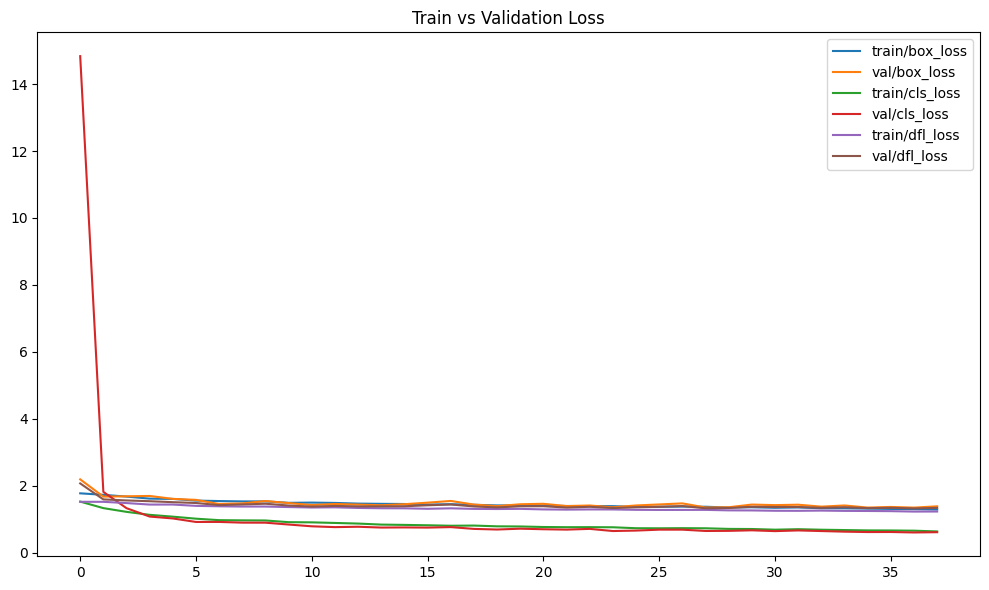

In [ ]:
# Plot train vs val loss
df[['train/box_loss', 'val/box_loss',
    'train/cls_loss', 'val/cls_loss',
    'train/dfl_loss', 'val/dfl_loss']].plot(figsize=(10, 6), title='Train vs Validation Loss')
plt.tight_layout()
plt.show()

Secara keseluruhan, model menunjukkan performa pembelajaran yang cukup baik karena seluruh metrik loss, yaitu train/box_loss, train/cls_loss, dan train/dfl_loss, mengalami penurunan secara konsisten pada data training maupun validation. Pada awal proses training terlihat adanya lonjakan yang cukup tinggi pada val/cls_loss, namun nilai tersebut turun drastis dalam beberapa epoch pertama dan kemudian menjadi stabil. Kondisi ini menunjukkan bahwa model dengan cepat mampu mempelajari karakteristik objek yang dideteksi, yaitu head dan helmet. Selain itu, kurva validation loss terus mengikuti pola training loss dengan selisih yang relatif kecil dan stabil hingga akhir training. Hal ini mengindikasikan bahwa model tidak mengalami overfitting yang signifikan dan memiliki kemampuan generalisasi yang baik terhadap data baru. Dengan demikian, proses training dapat dikatakan berhasil karena model telah mencapai kondisi yang cukup konvergen dan mampu menghasilkan performa yang stabil pada data validasi.


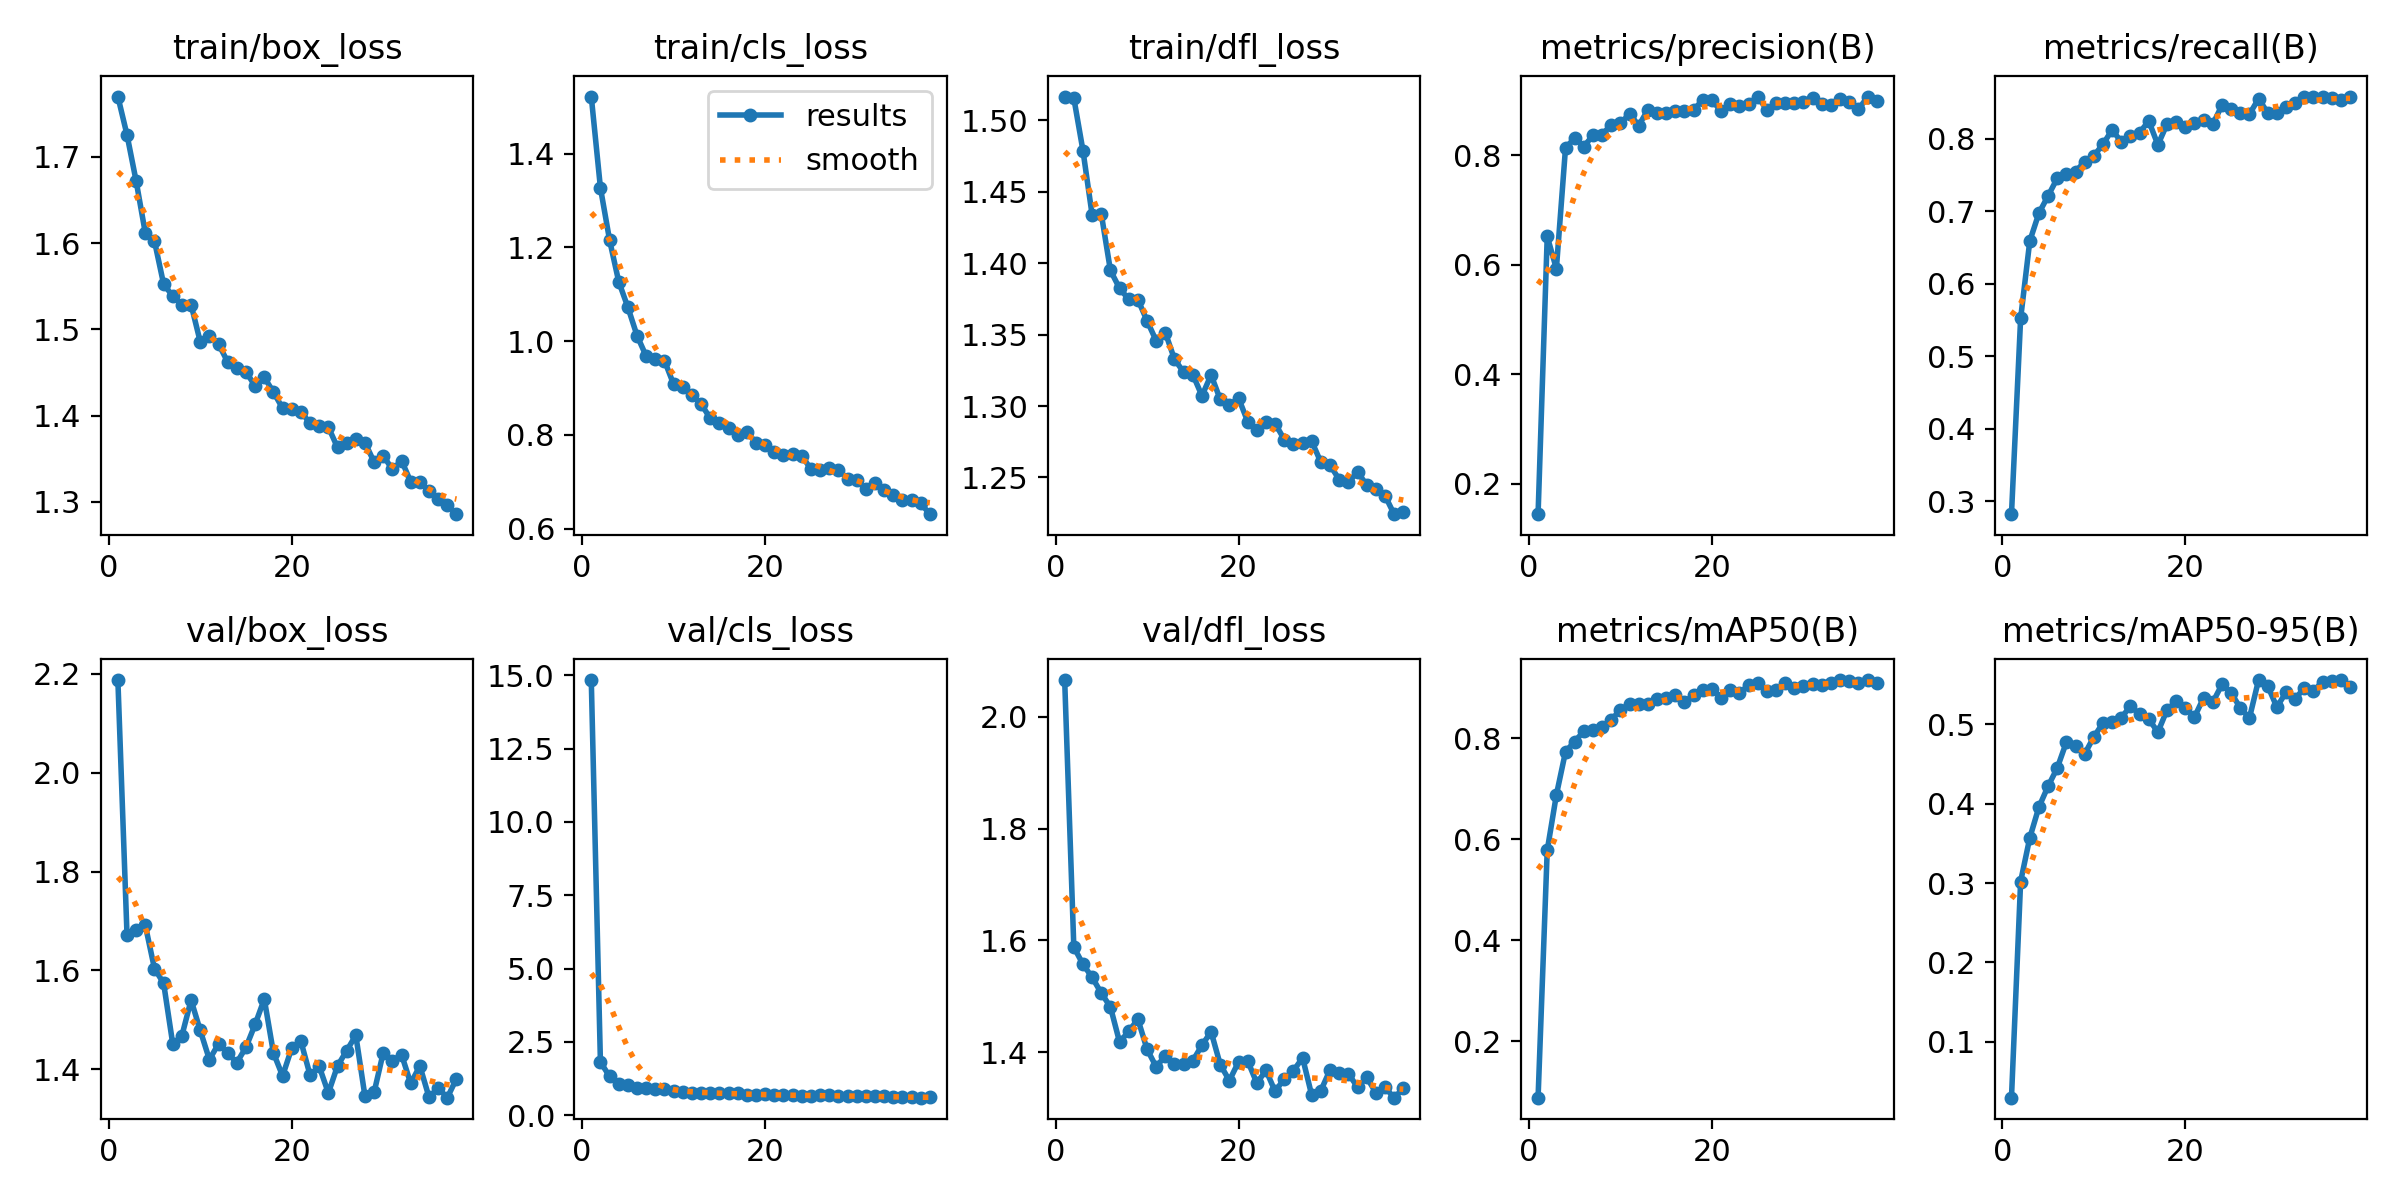

In [ ]:
from IPython.display import Image
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/results.png')


Berdasarkan grafik hasil pelatihan model, terlihat bahwa proses training berlangsung dengan baik dan menunjukkan konvergensi yang stabil. Hal ini ditunjukkan oleh penurunan yang konsisten pada seluruh metrik loss, yaitu train/box_loss, train/cls_loss, train/dfl_loss, serta diikuti oleh penurunan pada validation loss hingga akhir epoch. Meskipun terdapat lonjakan yang cukup tinggi pada val/cls_loss di awal pelatihan, nilai tersebut turun secara drastis dan kemudian stabil pada epoch-epoch berikutnya. Selain itu, pola penurunan loss pada data validasi tetap sejalan dengan data training tanpa adanya peningkatan yang signifikan, sehingga tidak terdapat indikasi overfitting yang berarti. Kondisi ini menunjukkan bahwa model mampu mempelajari pola pada data pelatihan sekaligus mempertahankan kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Dari sisi performa deteksi, nilai precision meningkat dengan cepat pada beberapa epoch awal dan mencapai sekitar 92% pada akhir pelatihan. Sementara itu, nilai recall terus meningkat hingga mencapai sekitar 85%. Nilai precision yang lebih tinggi dibandingkan recall menunjukkan bahwa sebagian besar prediksi yang dihasilkan model merupakan deteksi yang benar, sehingga jumlah *false positive* relatif rendah. Namun, masih terdapat sebagian kecil objek yang belum berhasil terdeteksi, yang tercermin dari nilai recall yang sedikit lebih rendah. Secara keseluruhan, kedua metrik tersebut menunjukkan performa deteksi yang baik dan cukup seimbang.

Performa model secara keseluruhan juga tercermin dari nilai mAP50 yang mencapai sekitar 91%, menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam mendeteksi objek pada ambang IoU 0,5. Di sisi lain, nilai mAP50-95 mencapai sekitar 55%, yang masih lebih rendah dibandingkan mAP50. Perbedaan ini mengindikasikan bahwa model sudah sangat baik dalam mengenali keberadaan objek head dan helmet, tetapi ketepatan lokalisasi bounding box pada ambang IoU yang lebih ketat masih dapat ditingkatkan. Dengan demikian, model telah berhasil mencapai performa deteksi yang tinggi, meskipun masih terdapat ruang perbaikan dalam meningkatkan presisi posisi dan ukuran bounding box.


In [ ]:

model_path = '/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/weights/best.pt'
model_best = YOLO(model_path)

model_best.val(
    data=yaml_path,
    split='test',
    project='/content/evaluations',
    name='yolov8m_test_eval',
    exist_ok=True
)

eval_path = '/content/evaluations/yolov8m_test_eval'
print(f"File hasil evaluasi ada di: {eval_path}")
print(os.listdir(eval_path))

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.7±6.3 MB/s, size: 50.1 KB)
val: Scanning /content/Hard-Hat-Detection-1/test/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 605.3it/s 0.8s
val: New cache created: /content/Hard-Hat-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.8it/s 18.2s
                   all        500       2621      0.923      0.845      0.916      0.558
                  head         99        764      0.923      0.823      0.902      0.547
                helmet        446       1857      0.923      0.866      0.931      0.569
Speed: 1.8ms preprocess, 28.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/evaluations/yolov8m_test_eval
File hasil 

Berdasarkan hasil evaluasi pada data test, model YOLOv8m menunjukkan performa yang sangat baik dengan Precision 92,3%, Recall 84,5%, mAP50 91,6%, dan mAP50-95 55,8%. Nilai precision yang tinggi menunjukkan bahwa sebagian besar prediksi model sudah benar, sedangkan recall yang sedikit lebih rendah mengindikasikan masih ada beberapa objek yang belum terdeteksi. Nilai mAP50 sebesar 91,6% menunjukkan kemampuan deteksi yang sangat baik pada ambang batas IoU standar. Namun, nilai mAP50-95 sebesar 55,8% yang jauh lebih rendah dibandingkan mAP50 menunjukkan bahwa meskipun model mampu mengenali objek dengan baik, ketepatan dalam menentukan posisi dan ukuran bounding box pada berbagai ambang IoU yang lebih ketat masih dapat ditingkatkan.

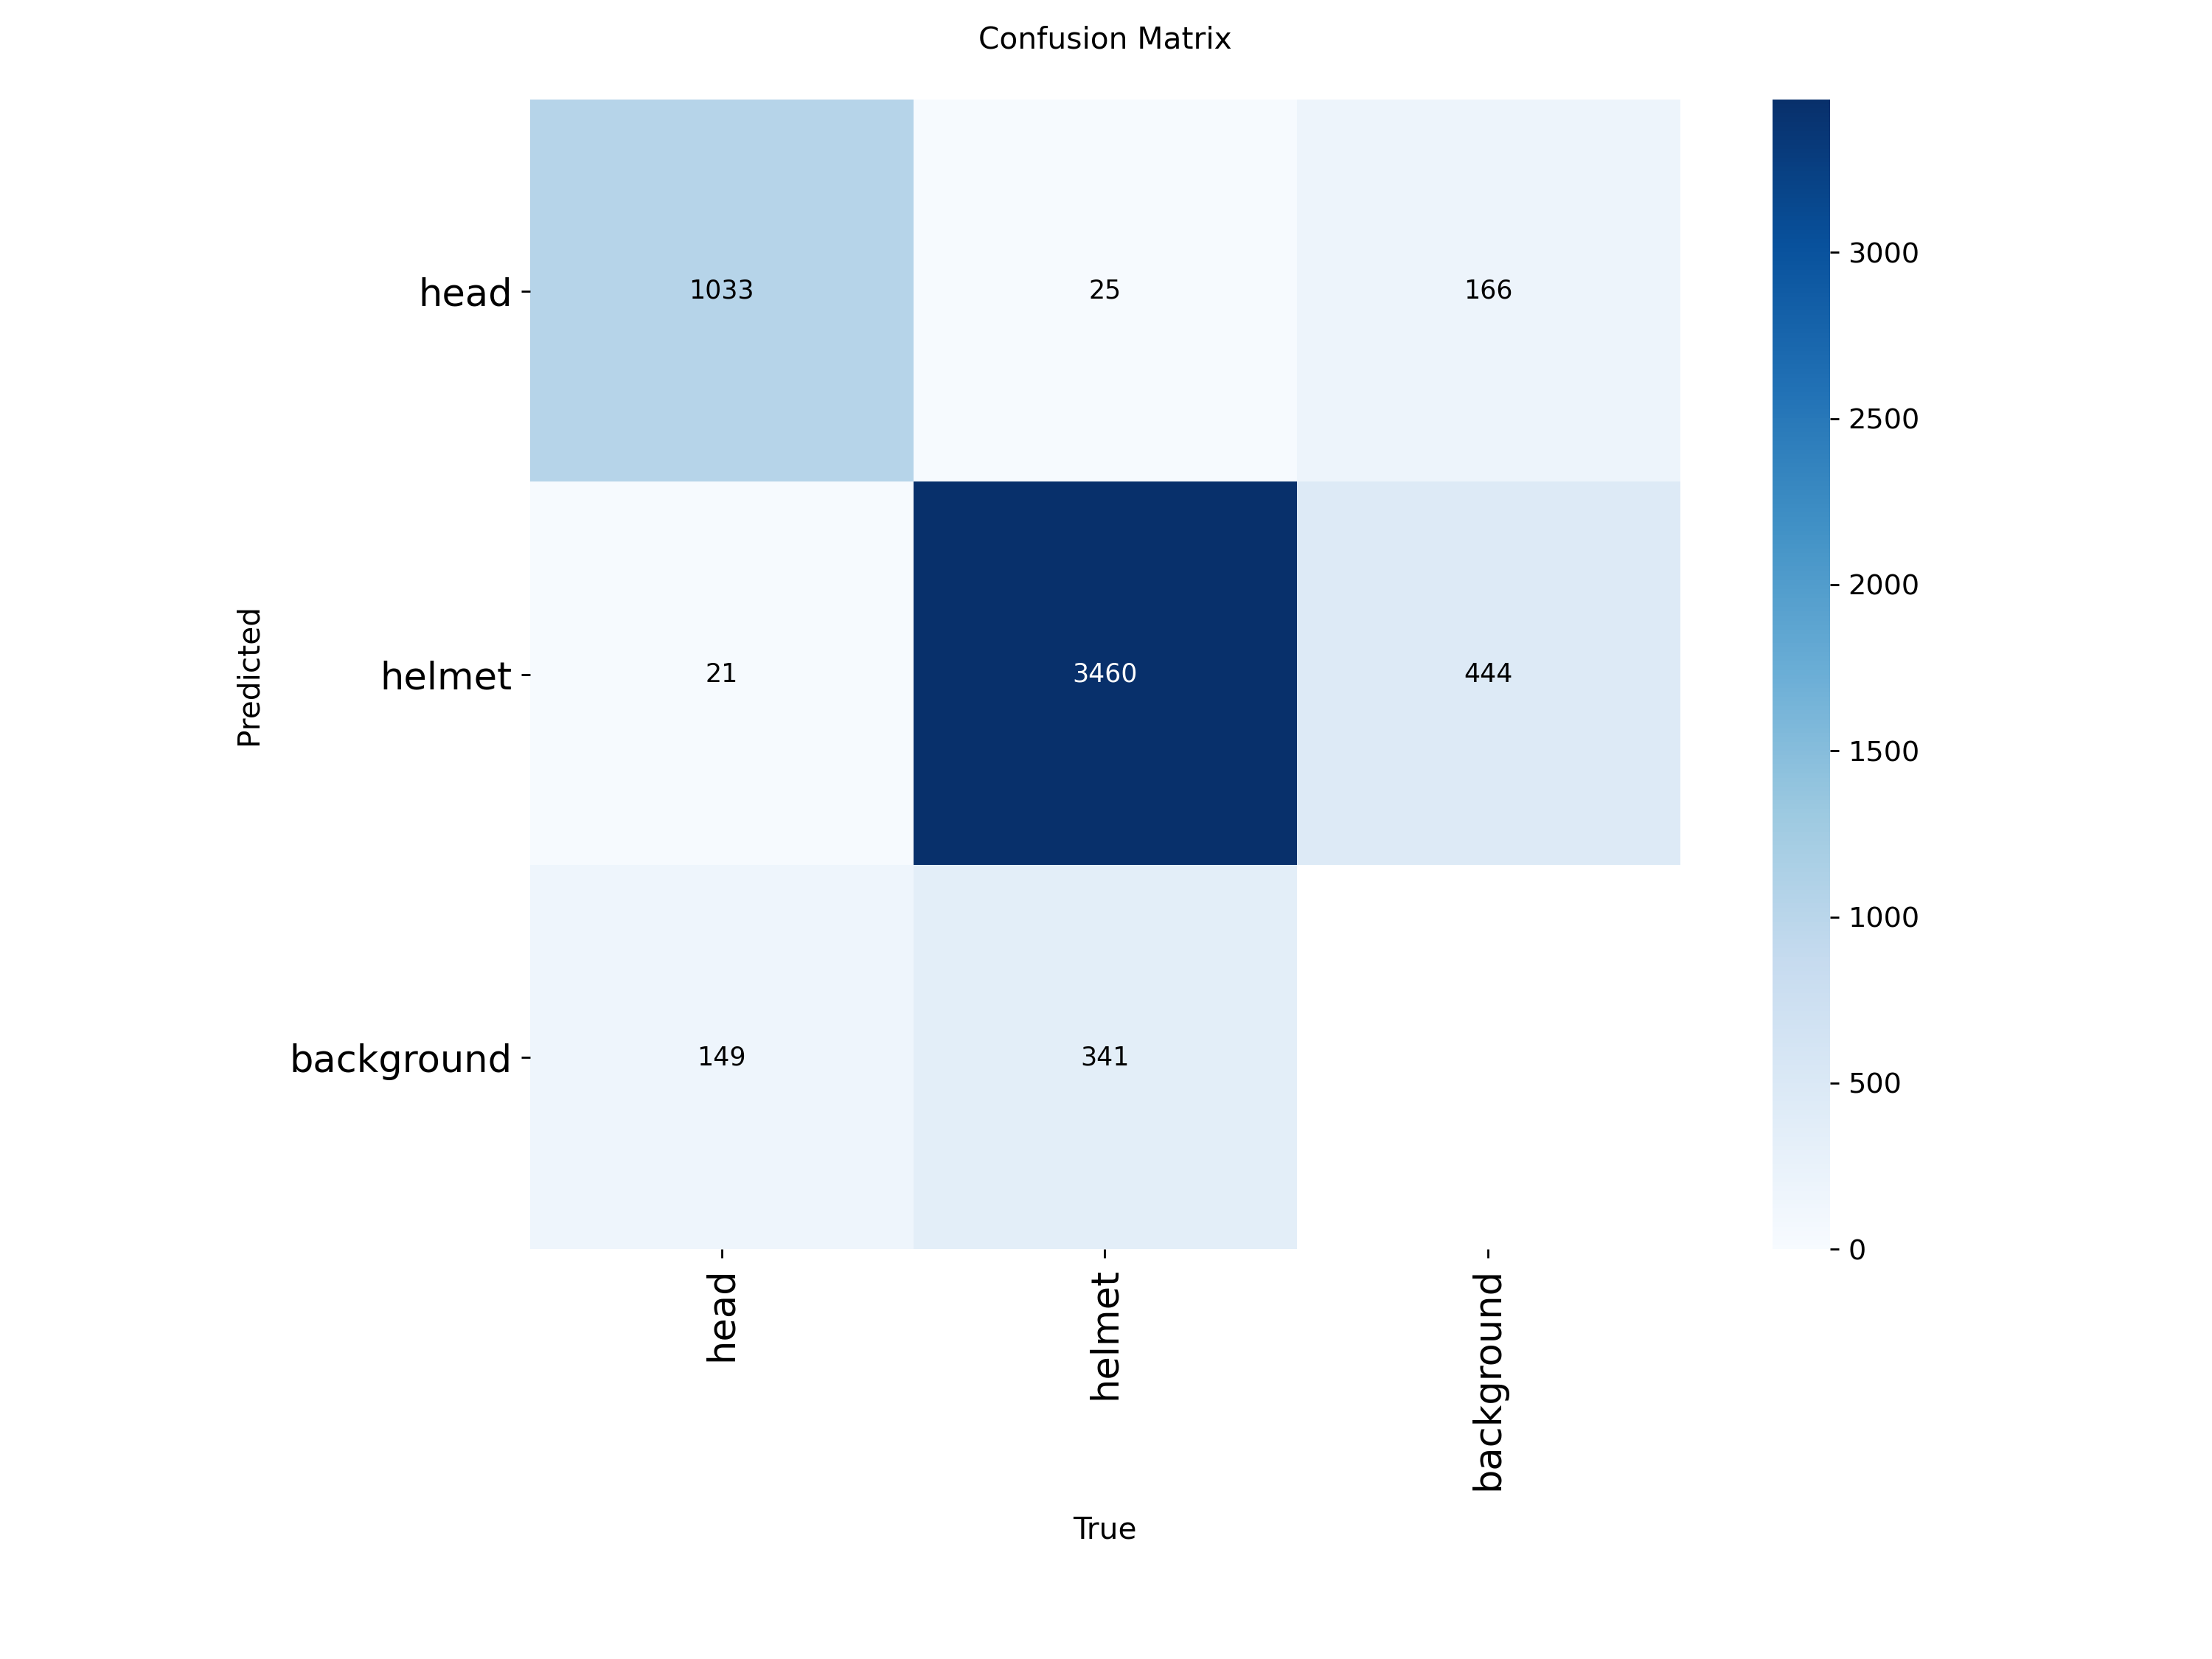

In [ ]:
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/confusion_matrix.png')

Model menunjukkan performa klasifikasi yang sangat baik dalam membedakan antara objek head dan helmet. Model berhasil mengidentifikasi dengan benar 1033 instansi head dan 3460 instansi helmet. Tingkat kebingungan antar kedua kelas juga relatif rendah, di mana hanya terdapat 25 instansi helmet yang salah diprediksi sebagai head dan 21 instansi head yang salah diprediksi sebagai helmet. Selain itu, model masih menghadapi tantangan dalam membedakan objek dengan latar belakang, yang terlihat dari 166 kasus latar belakang yang diprediksi sebagai head dan 444 kasus latar belakang yang diprediksi sebagai helmet. Di sisi lain, terdapat 149 objek head dan 341 objek helmet yang tidak berhasil terdeteksi sehingga terklasifikasi sebagai latar belakang.

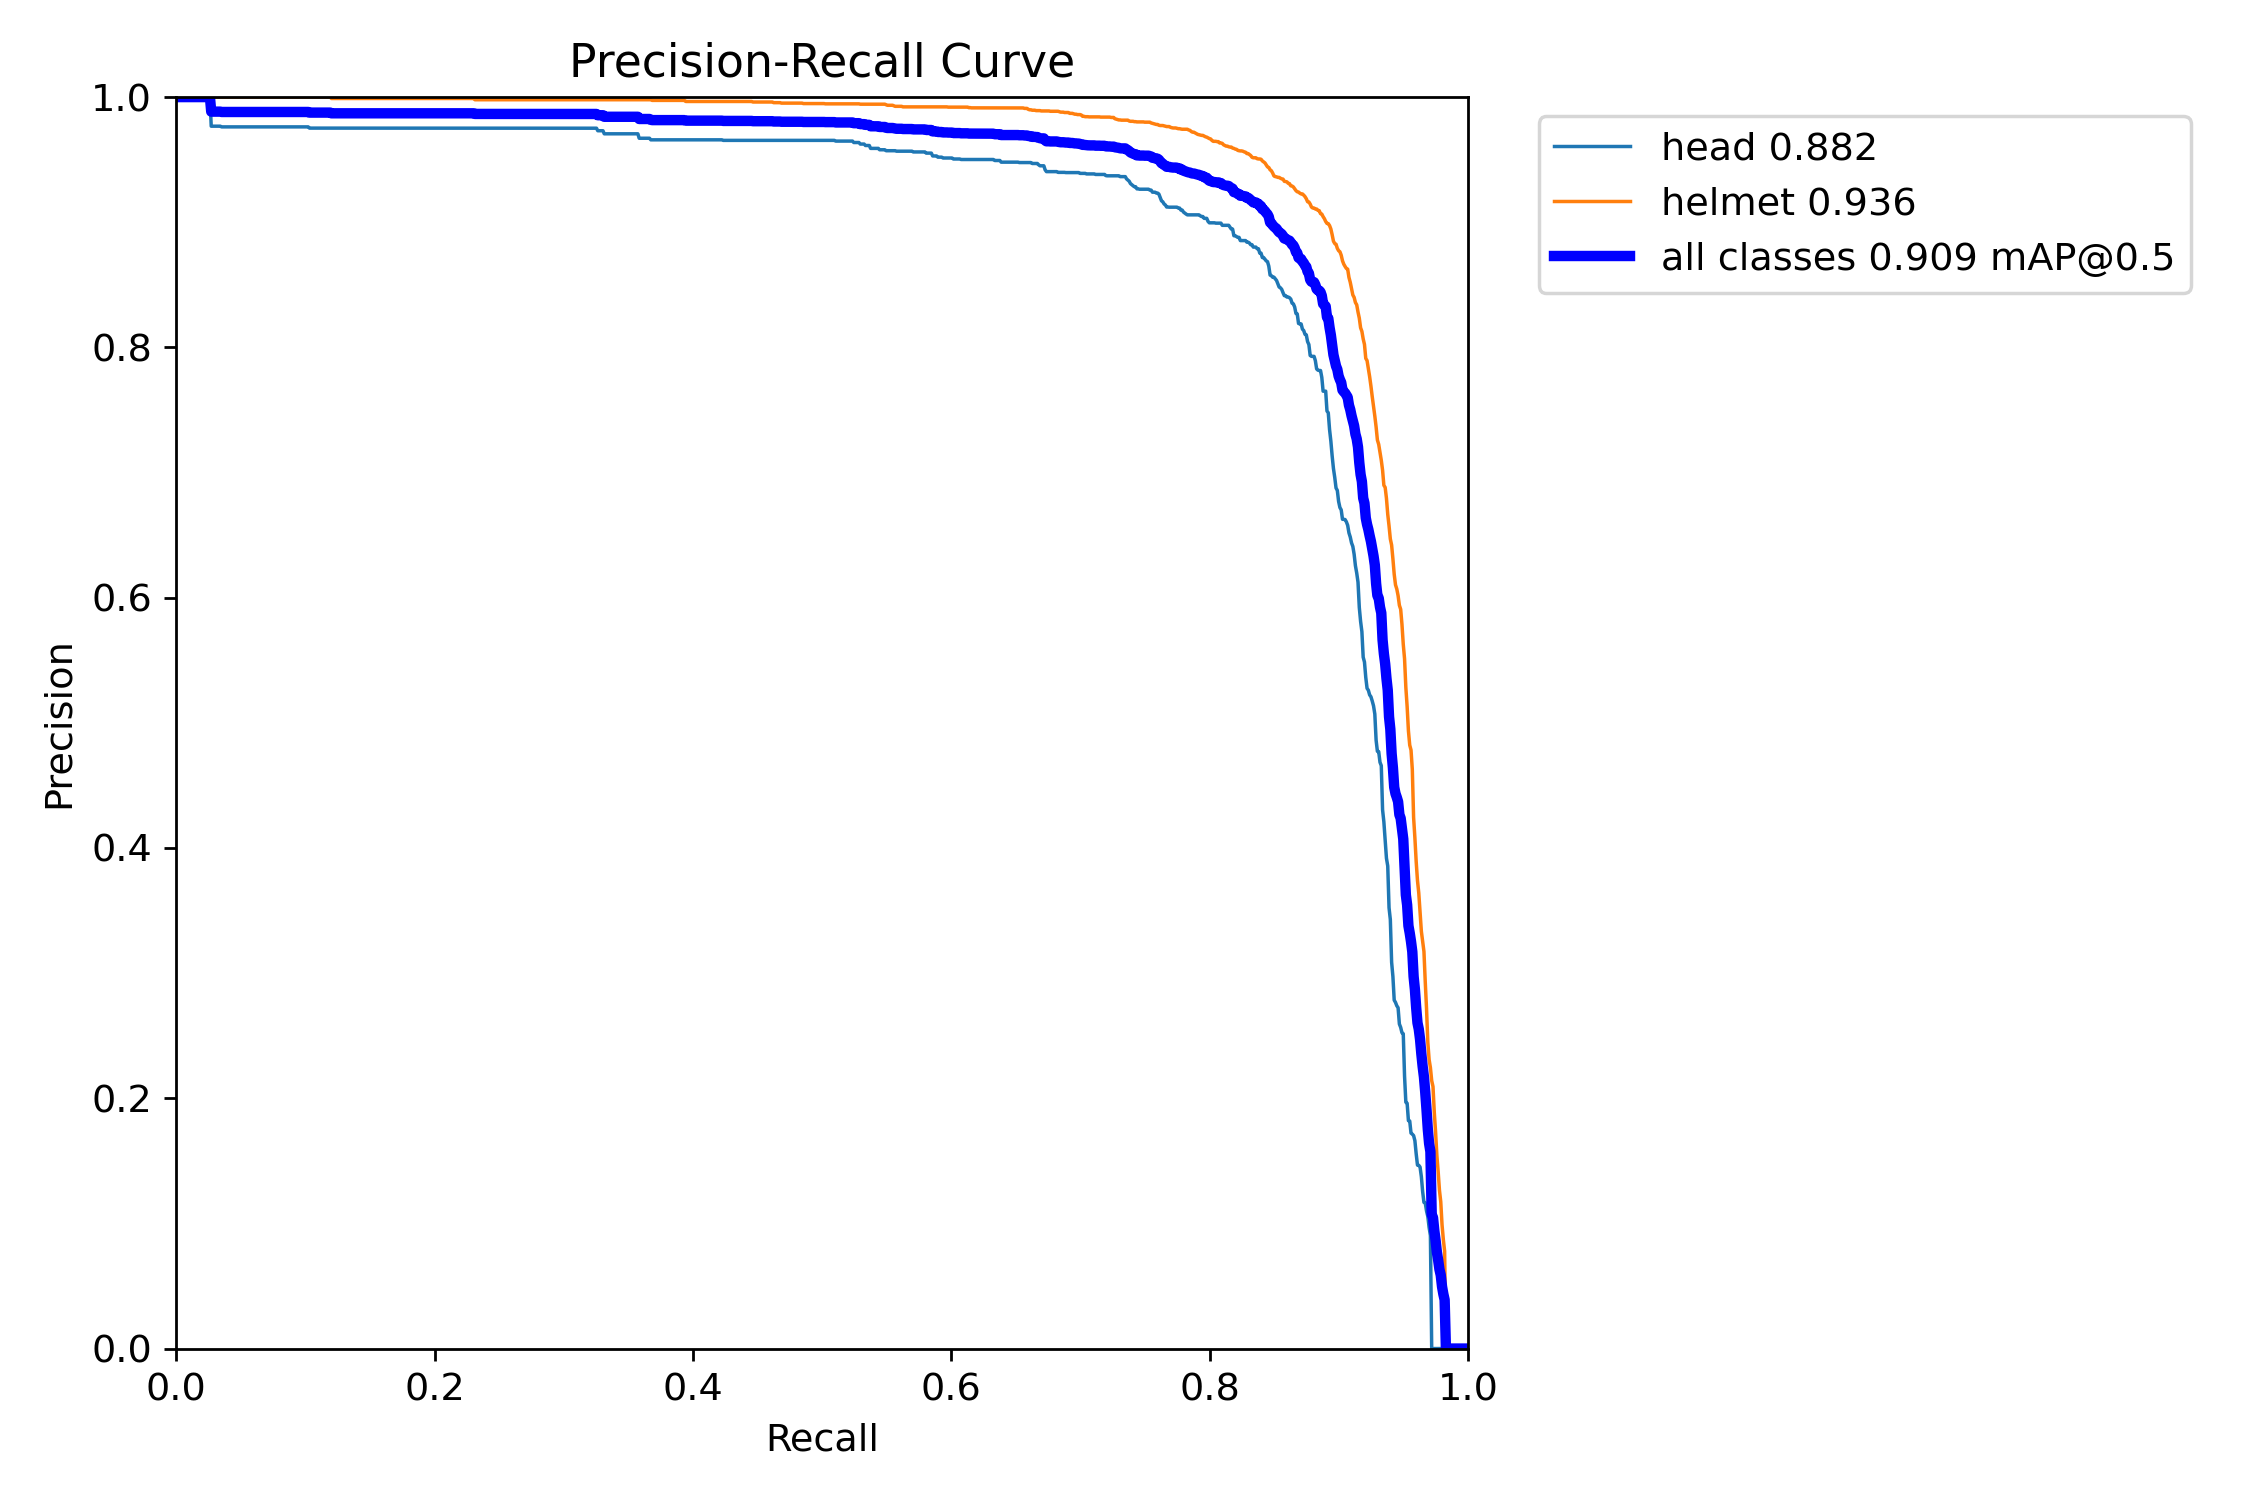

In [ ]:
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/BoxPR_curve.png')

Grafik Precision-Recall menunjukkan bahwa kelas helmet memiliki performa terbaik dengan nilai AP sekitar 93,6%, yang ditunjukkan oleh kurva yang tetap berada di area atas grafik dan mendekati sudut kanan atas. Hal ini menunjukkan bahwa model sangat akurat dan konsisten dalam mendeteksi objek helmet. Kelas head juga memiliki performa yang baik dengan nilai AP sekitar 88,2%, meskipun terlihat penurunan precision ketika recall mendekati nilai maksimum, yang menandakan masih terdapat beberapa kesalahan deteksi pada kondisi tertentu. Secara keseluruhan, nilai mAP@0.5 sebesar 90,9% menunjukkan bahwa model memiliki kemampuan deteksi yang sangat baik pada kedua kelas, dengan performa deteksi helmet yang sedikit lebih unggul dibandingkan head.

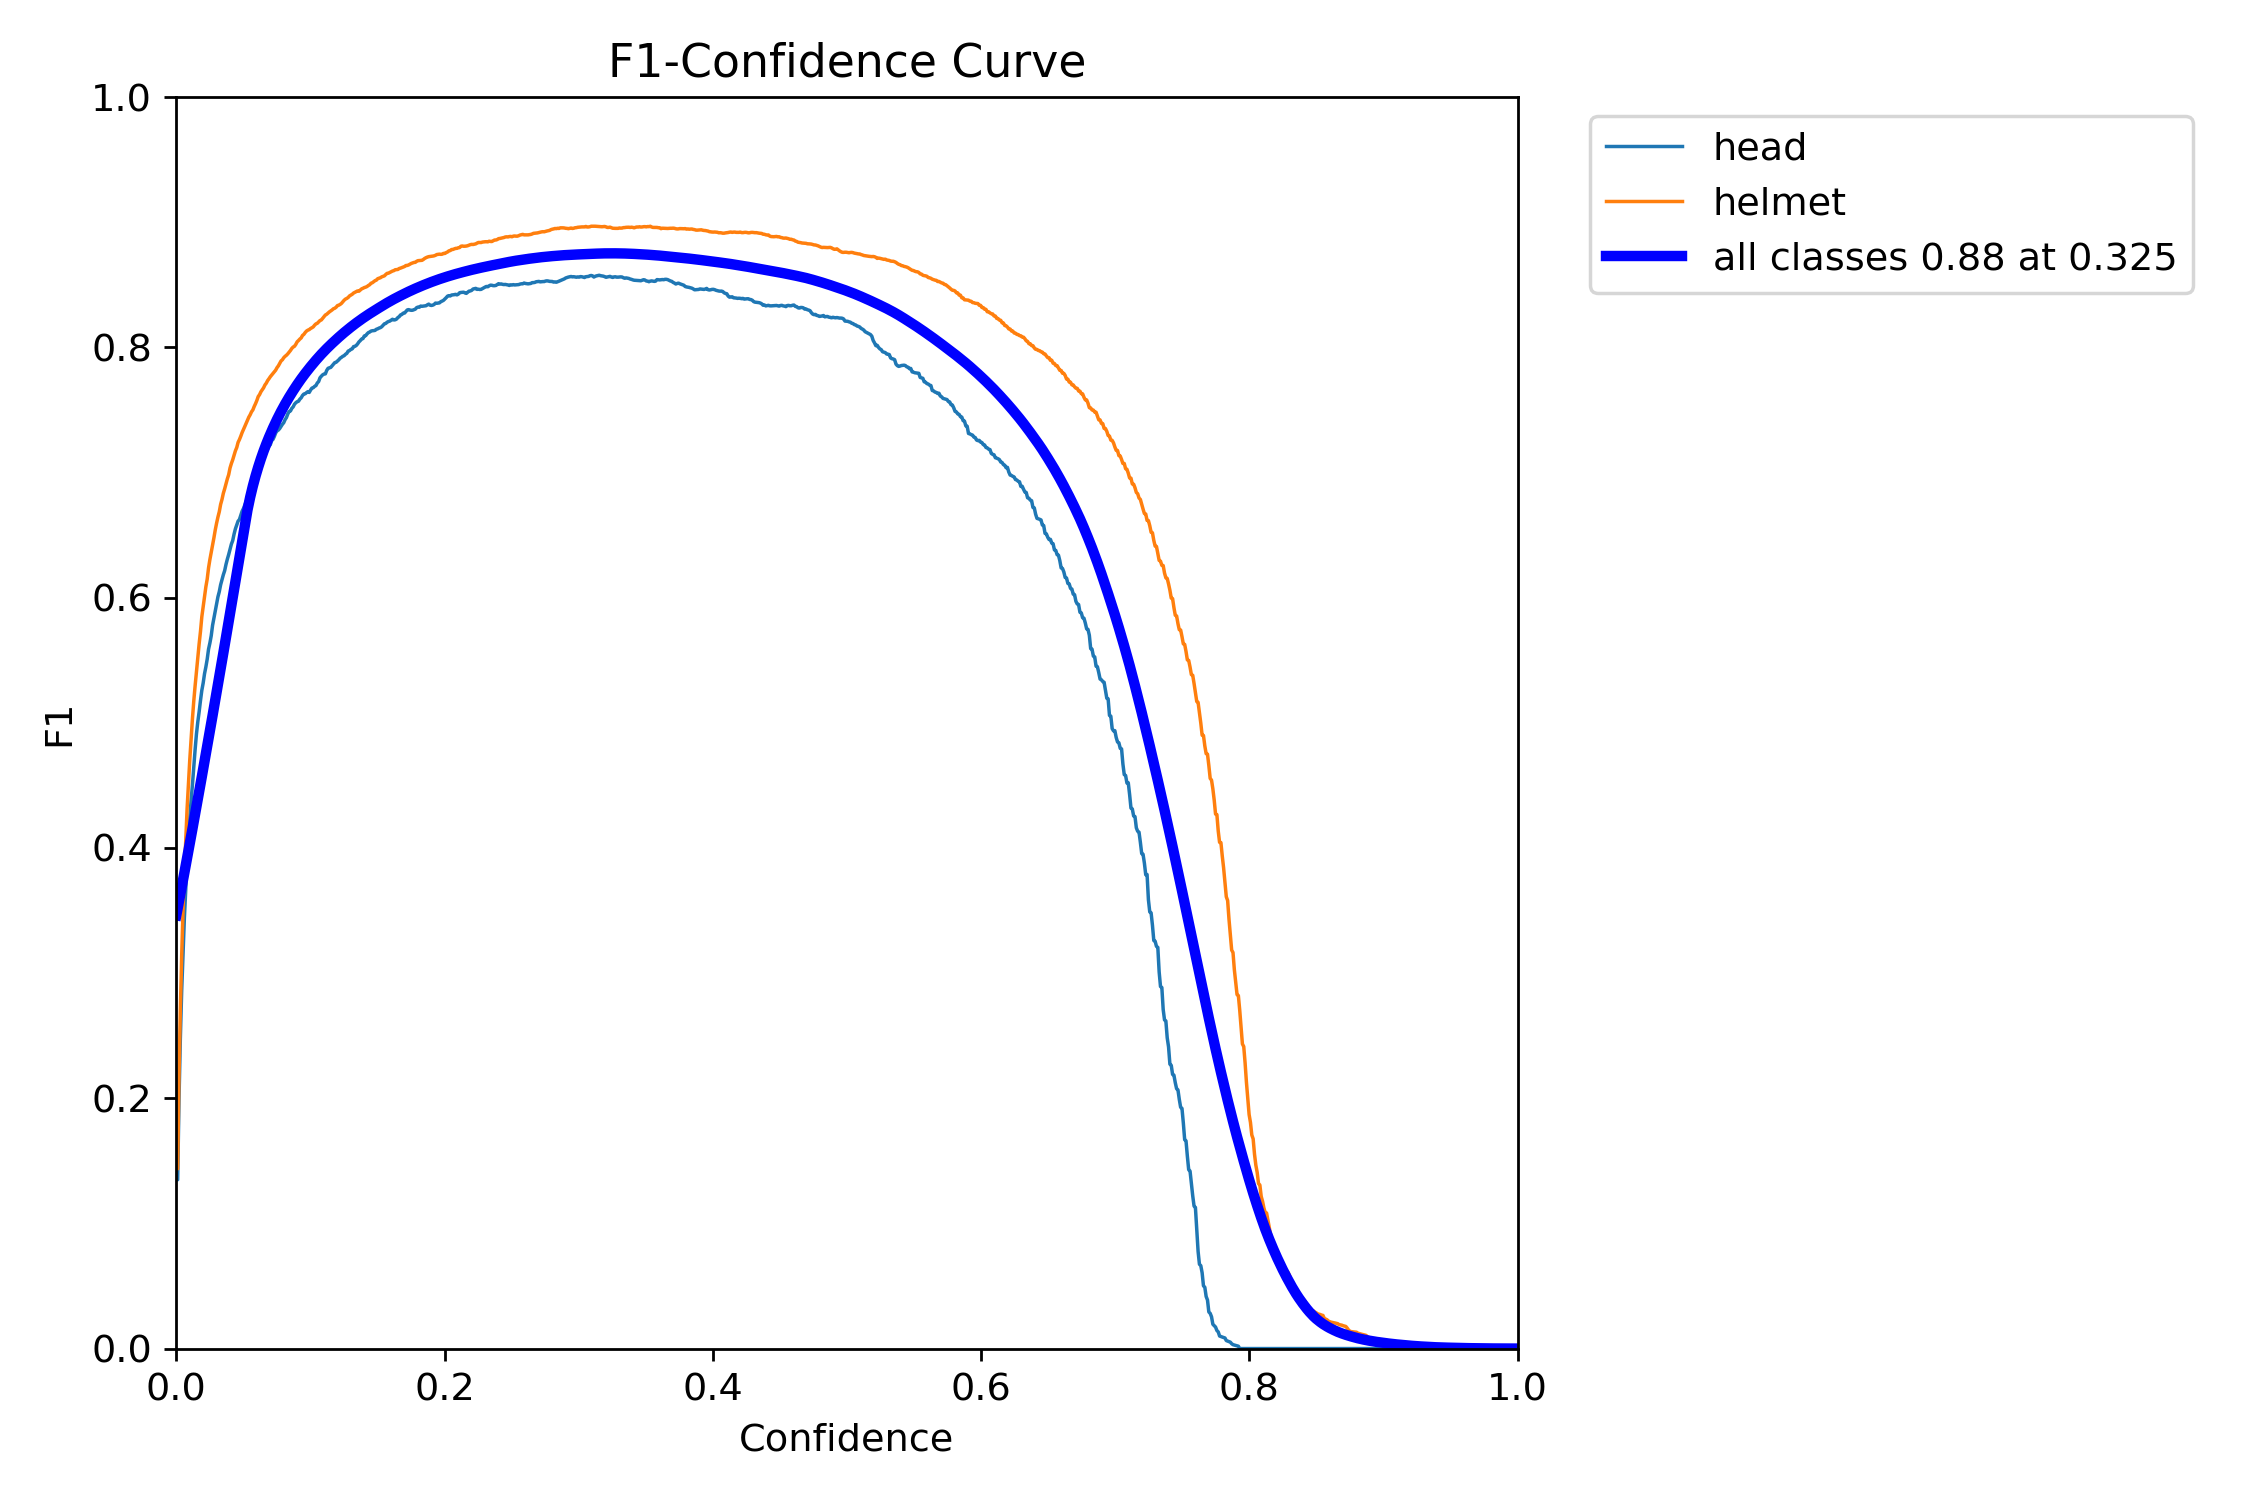

In [ ]:
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/BoxF1_curve.png')

Grafik F1-Confidence yang disajikan pada gambar memberikan gambaran mengenai keseimbangan antara precision dan recall pada berbagai tingkat confidence threshold. Secara keseluruhan, model mencapai nilai F1-score maksimum sebesar 0,88 pada confidence threshold 0,325, yang menunjukkan titik keseimbangan paling optimal untuk seluruh kelas. Jika diamati per kelas, kurva helmet secara konsisten berada sedikit di atas kurva head, yang mengindikasikan bahwa model memiliki performa yang lebih baik dalam menjaga keseimbangan antara precision dan recall untuk deteksi helmet dibandingkan deteksi head. Selain itu, pola kurva yang meningkat pada awal threshold, kemudian mencapai puncak dan menurun pada threshold yang lebih tinggi, menunjukkan bahwa model bekerja paling optimal pada rentang confidence sekitar 0,2 hingga 0,5. Pada rentang tersebut, model mampu menghasilkan prediksi yang akurat tanpa mengorbankan terlalu banyak objek yang seharusnya terdeteksi.

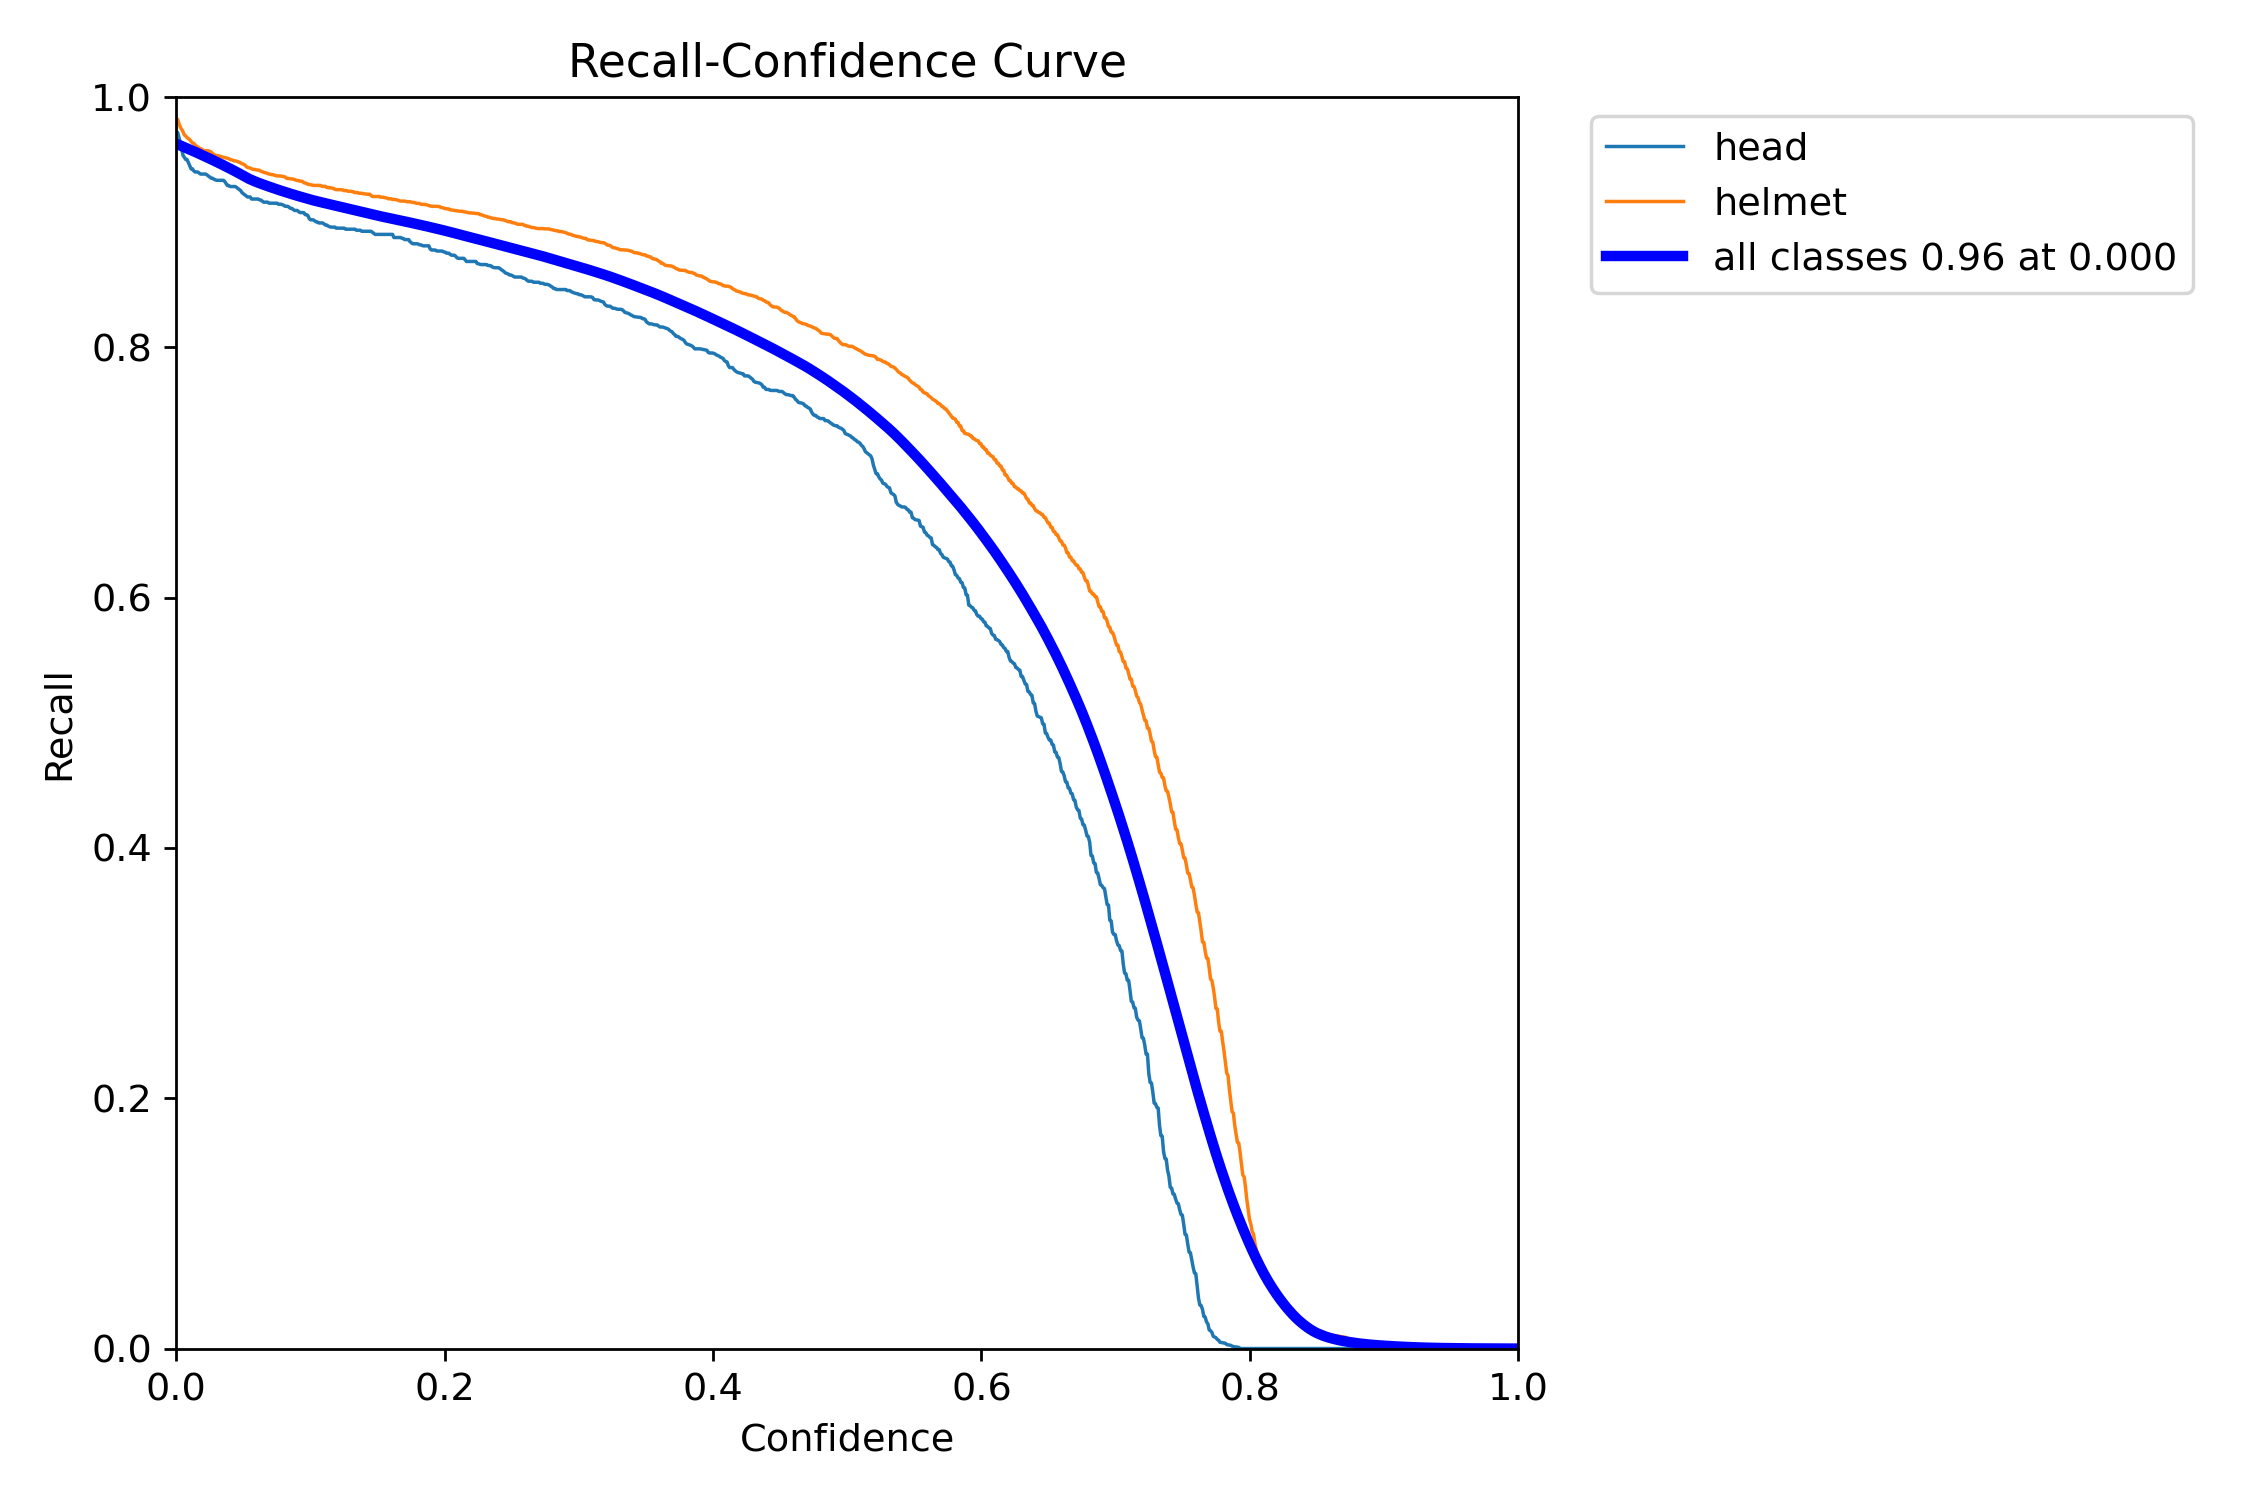

In [ ]:
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/BoxR_curve.png')

Grafik Recall-Confidence Curve menunjukkan bahwa nilai recall tertinggi dicapai pada confidence threshold yang sangat rendah, yaitu sekitar 0,96 pada threshold 0,0. Seiring meningkatnya confidence threshold, nilai recall pada kedua kelas mengalami penurunan secara bertahap karena model menjadi lebih selektif dalam menerima prediksi. Kelas helmet mempertahankan nilai recall yang sedikit lebih tinggi dibandingkan kelas head di hampir seluruh rentang confidence, yang menunjukkan bahwa model lebih konsisten dalam mendeteksi objek helmet. Namun, ketika confidence threshold melebihi sekitar 0,7, nilai recall pada kedua kelas menurun dengan sangat cepat, menandakan semakin banyak objek yang tidak terdeteksi. Secara keseluruhan, grafik ini menunjukkan adanya trade-off antara confidence dan recall, sehingga penggunaan confidence threshold yang terlalu tinggi dapat mengurangi kemampuan model dalam menemukan seluruh objek yang ada pada gambar.


image 1/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1006_png.rf.256a979b0b85f9d8b2a68bd16af7e51b.jpg: 640x640 15 heads, 4 helmets, 36.8ms
image 2/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1018_png.rf.c50cb2c577064fbba7d47fb649da56ae.jpg: 640x640 3 helmets, 36.9ms
image 3/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1019_png.rf.9222efe332c6efb697531806a0c11125.jpg: 640x640 2 helmets, 36.9ms
image 4/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1020_png.rf.baa8a9818b49f4c547ed8ce1f30511cd.jpg: 640x640 8 helmets, 34.5ms
image 5/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1022_png.rf.9160c68da3e2854d01493902e1669fa0.jpg: 640x640 4 helmets, 33.9ms
image 6/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1023_png.rf.1628f4d867cfadb3564d456526e1ad7f.jpg: 640x640 6 helmets, 34.0ms
image 7/500 /content/Hard-Hat-Detection-1/test/images/hard_hat_workers1025_png.rf.65552c36a3a31e7638d84a10abf97d9

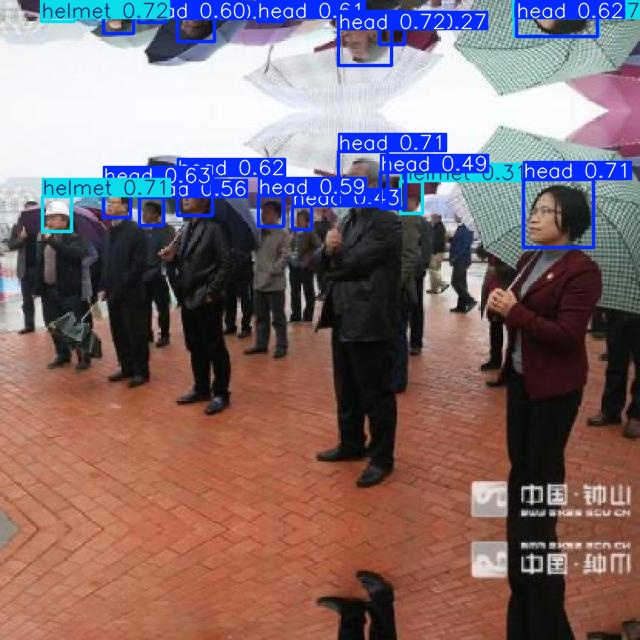

In [ ]:
results = model_best.predict(
    source=os.path.join(dataset_path, 'test/images'),
    save=True,
    conf=0.25
)

saved_image_path = os.path.join(results[0].save_dir, os.path.basename(results[0].path))
display(Image(saved_image_path))

Model berhasil mengenali sebagian besar objek head dan helmet pada kerumunan orang dengan tingkat kepercayaan yang cukup baik dimulai dari 0,49 hingga 0,72. Model mampu mendeteksi banyak kepala dan helm meskipun objek berukuran kecil dan saling berdekatan. Namun, masih terlihat beberapa prediksi dengan confidence yang relatif rendah serta kemungkinan deteksi yang kurang akurat akibat kondisi objek yang tertutup (occlusion) dan kepadatan kerumunan.

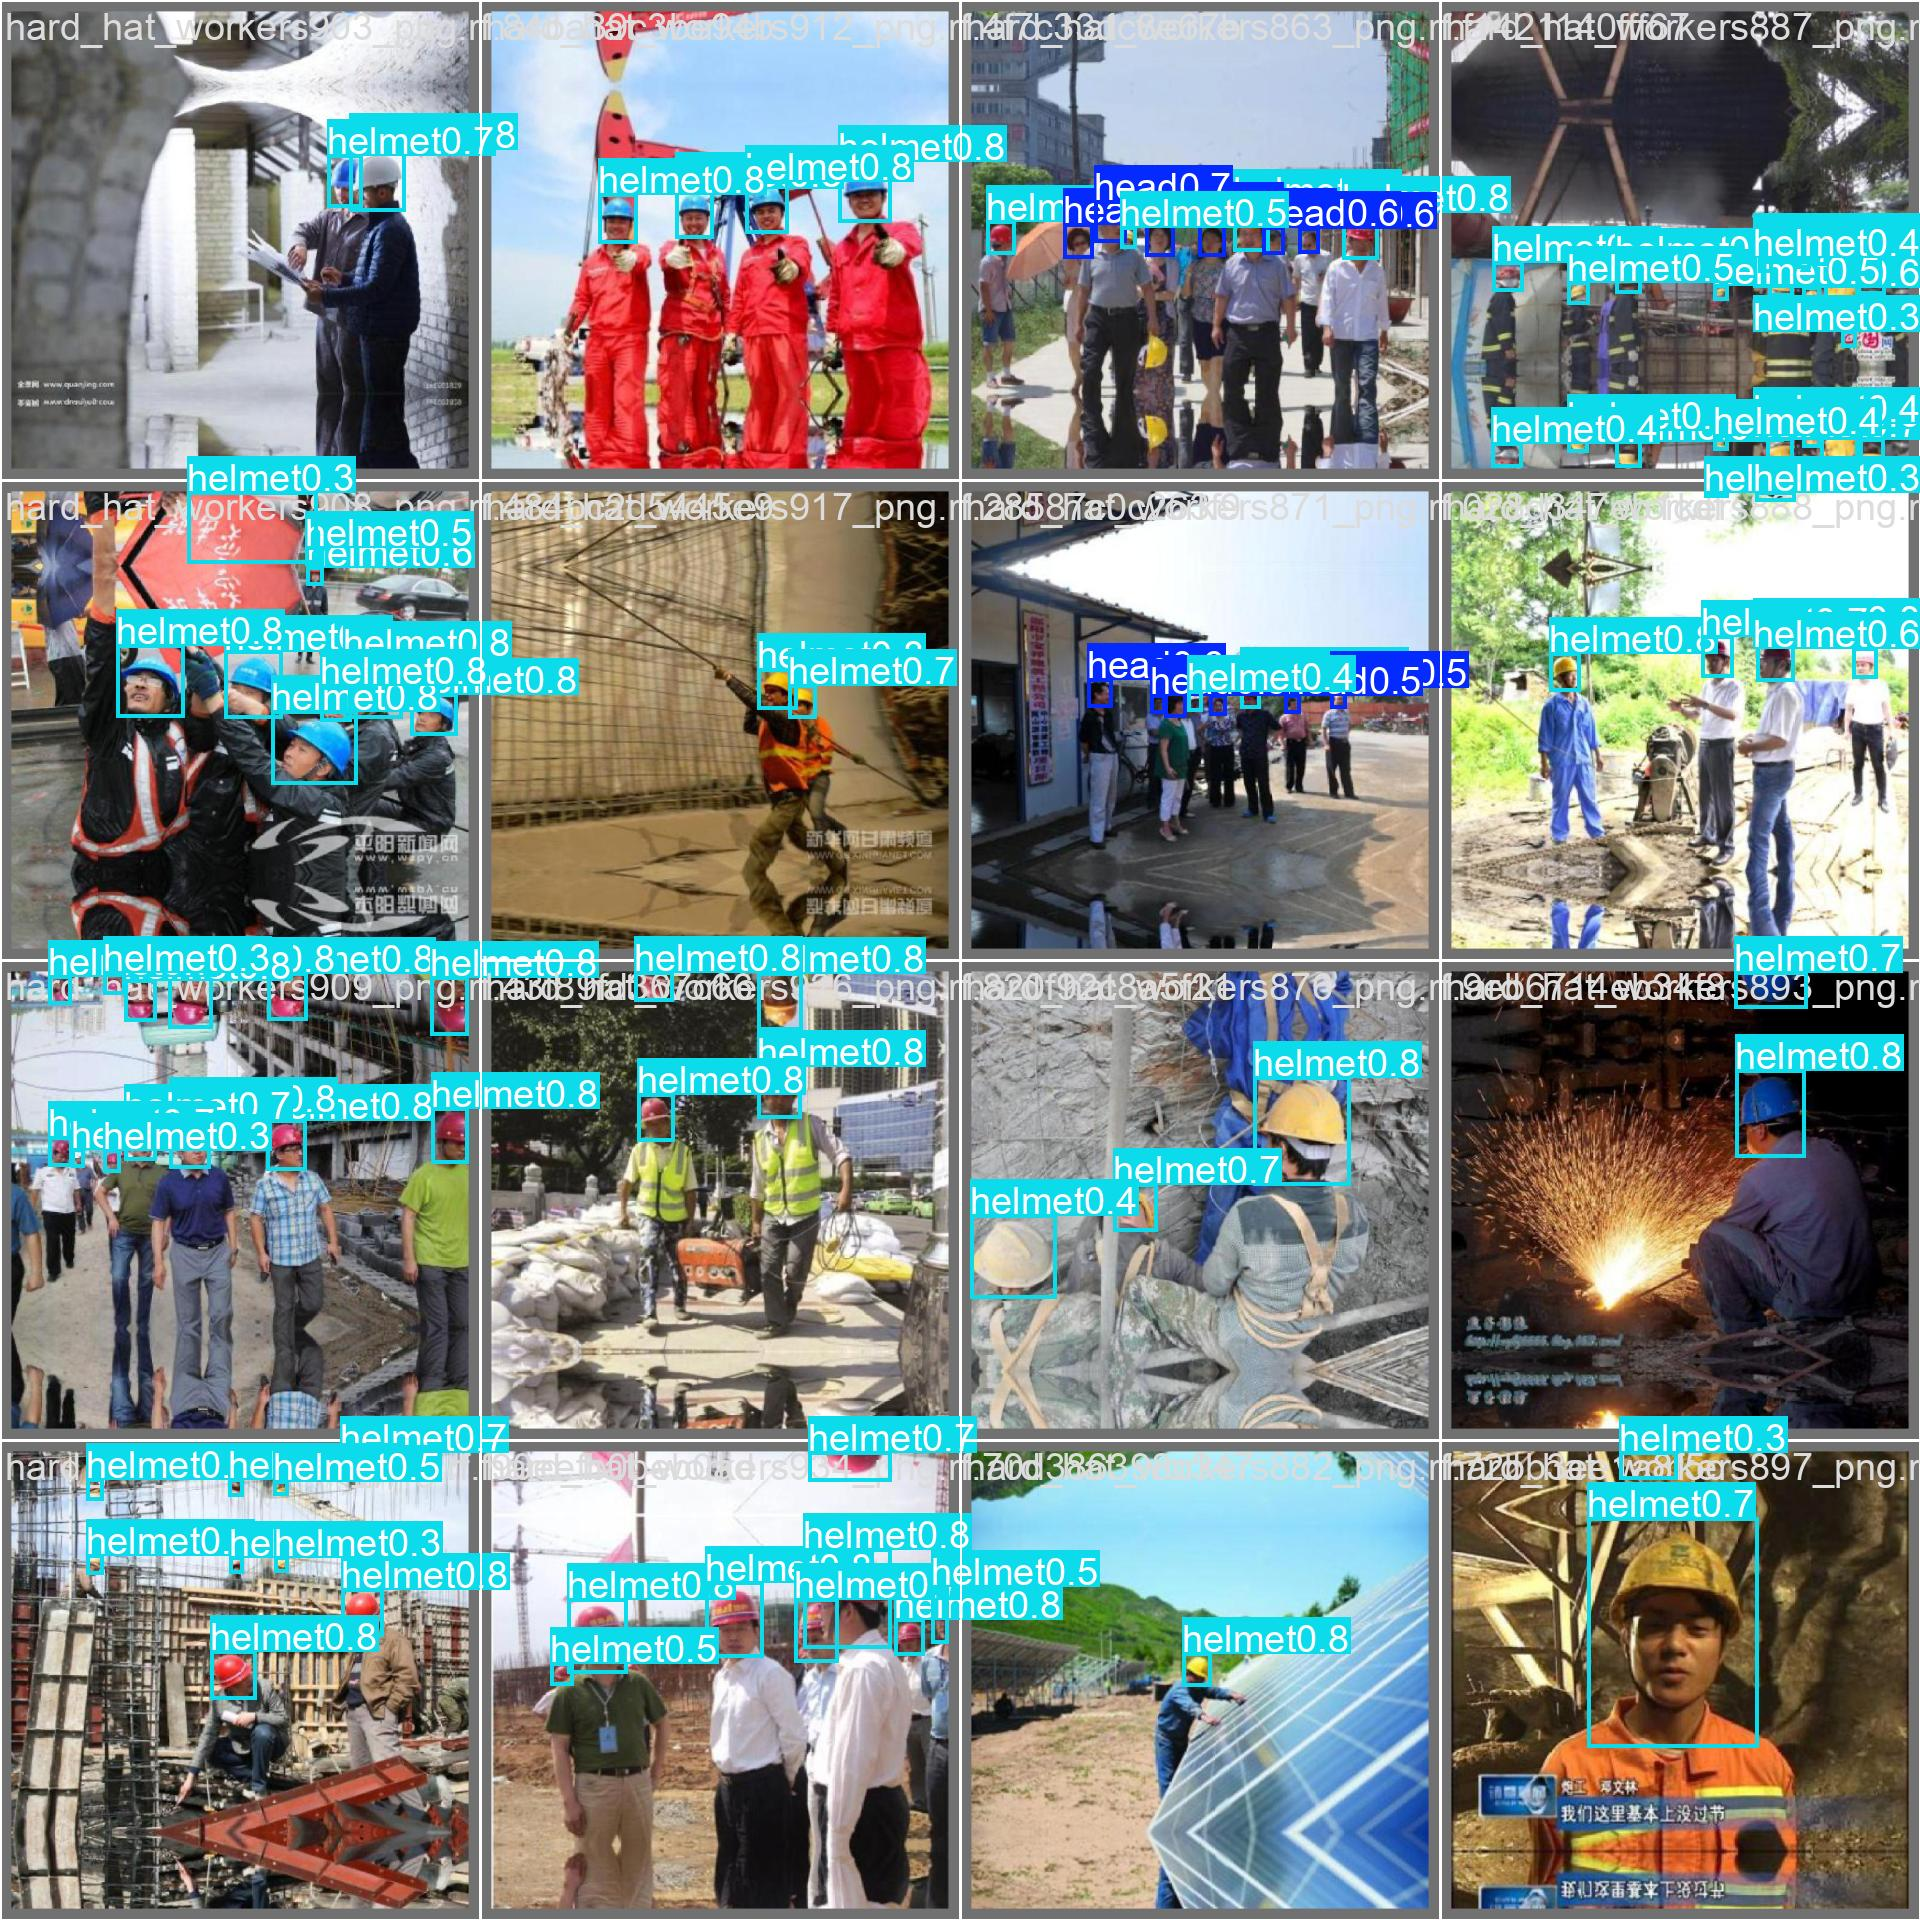

In [ ]:
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/val_batch0_pred.jpg')

Sebagian besar objek berhasil terdeteksi dengan nilai confidence yang cukup tinggi, umumnya berada pada rentang 0,5–0,8, yang menunjukkan tingkat keyakinan prediksi yang baik. Model juga mampu mengenali objek pada berbagai ukuran, sudut pandang, dan jumlah pekerja dalam satu gambar. Meskipun masih terdapat beberapa prediksi dengan confidence yang lebih rendah dan beberapa objek yang tidak terdeteksi secara sempurna.

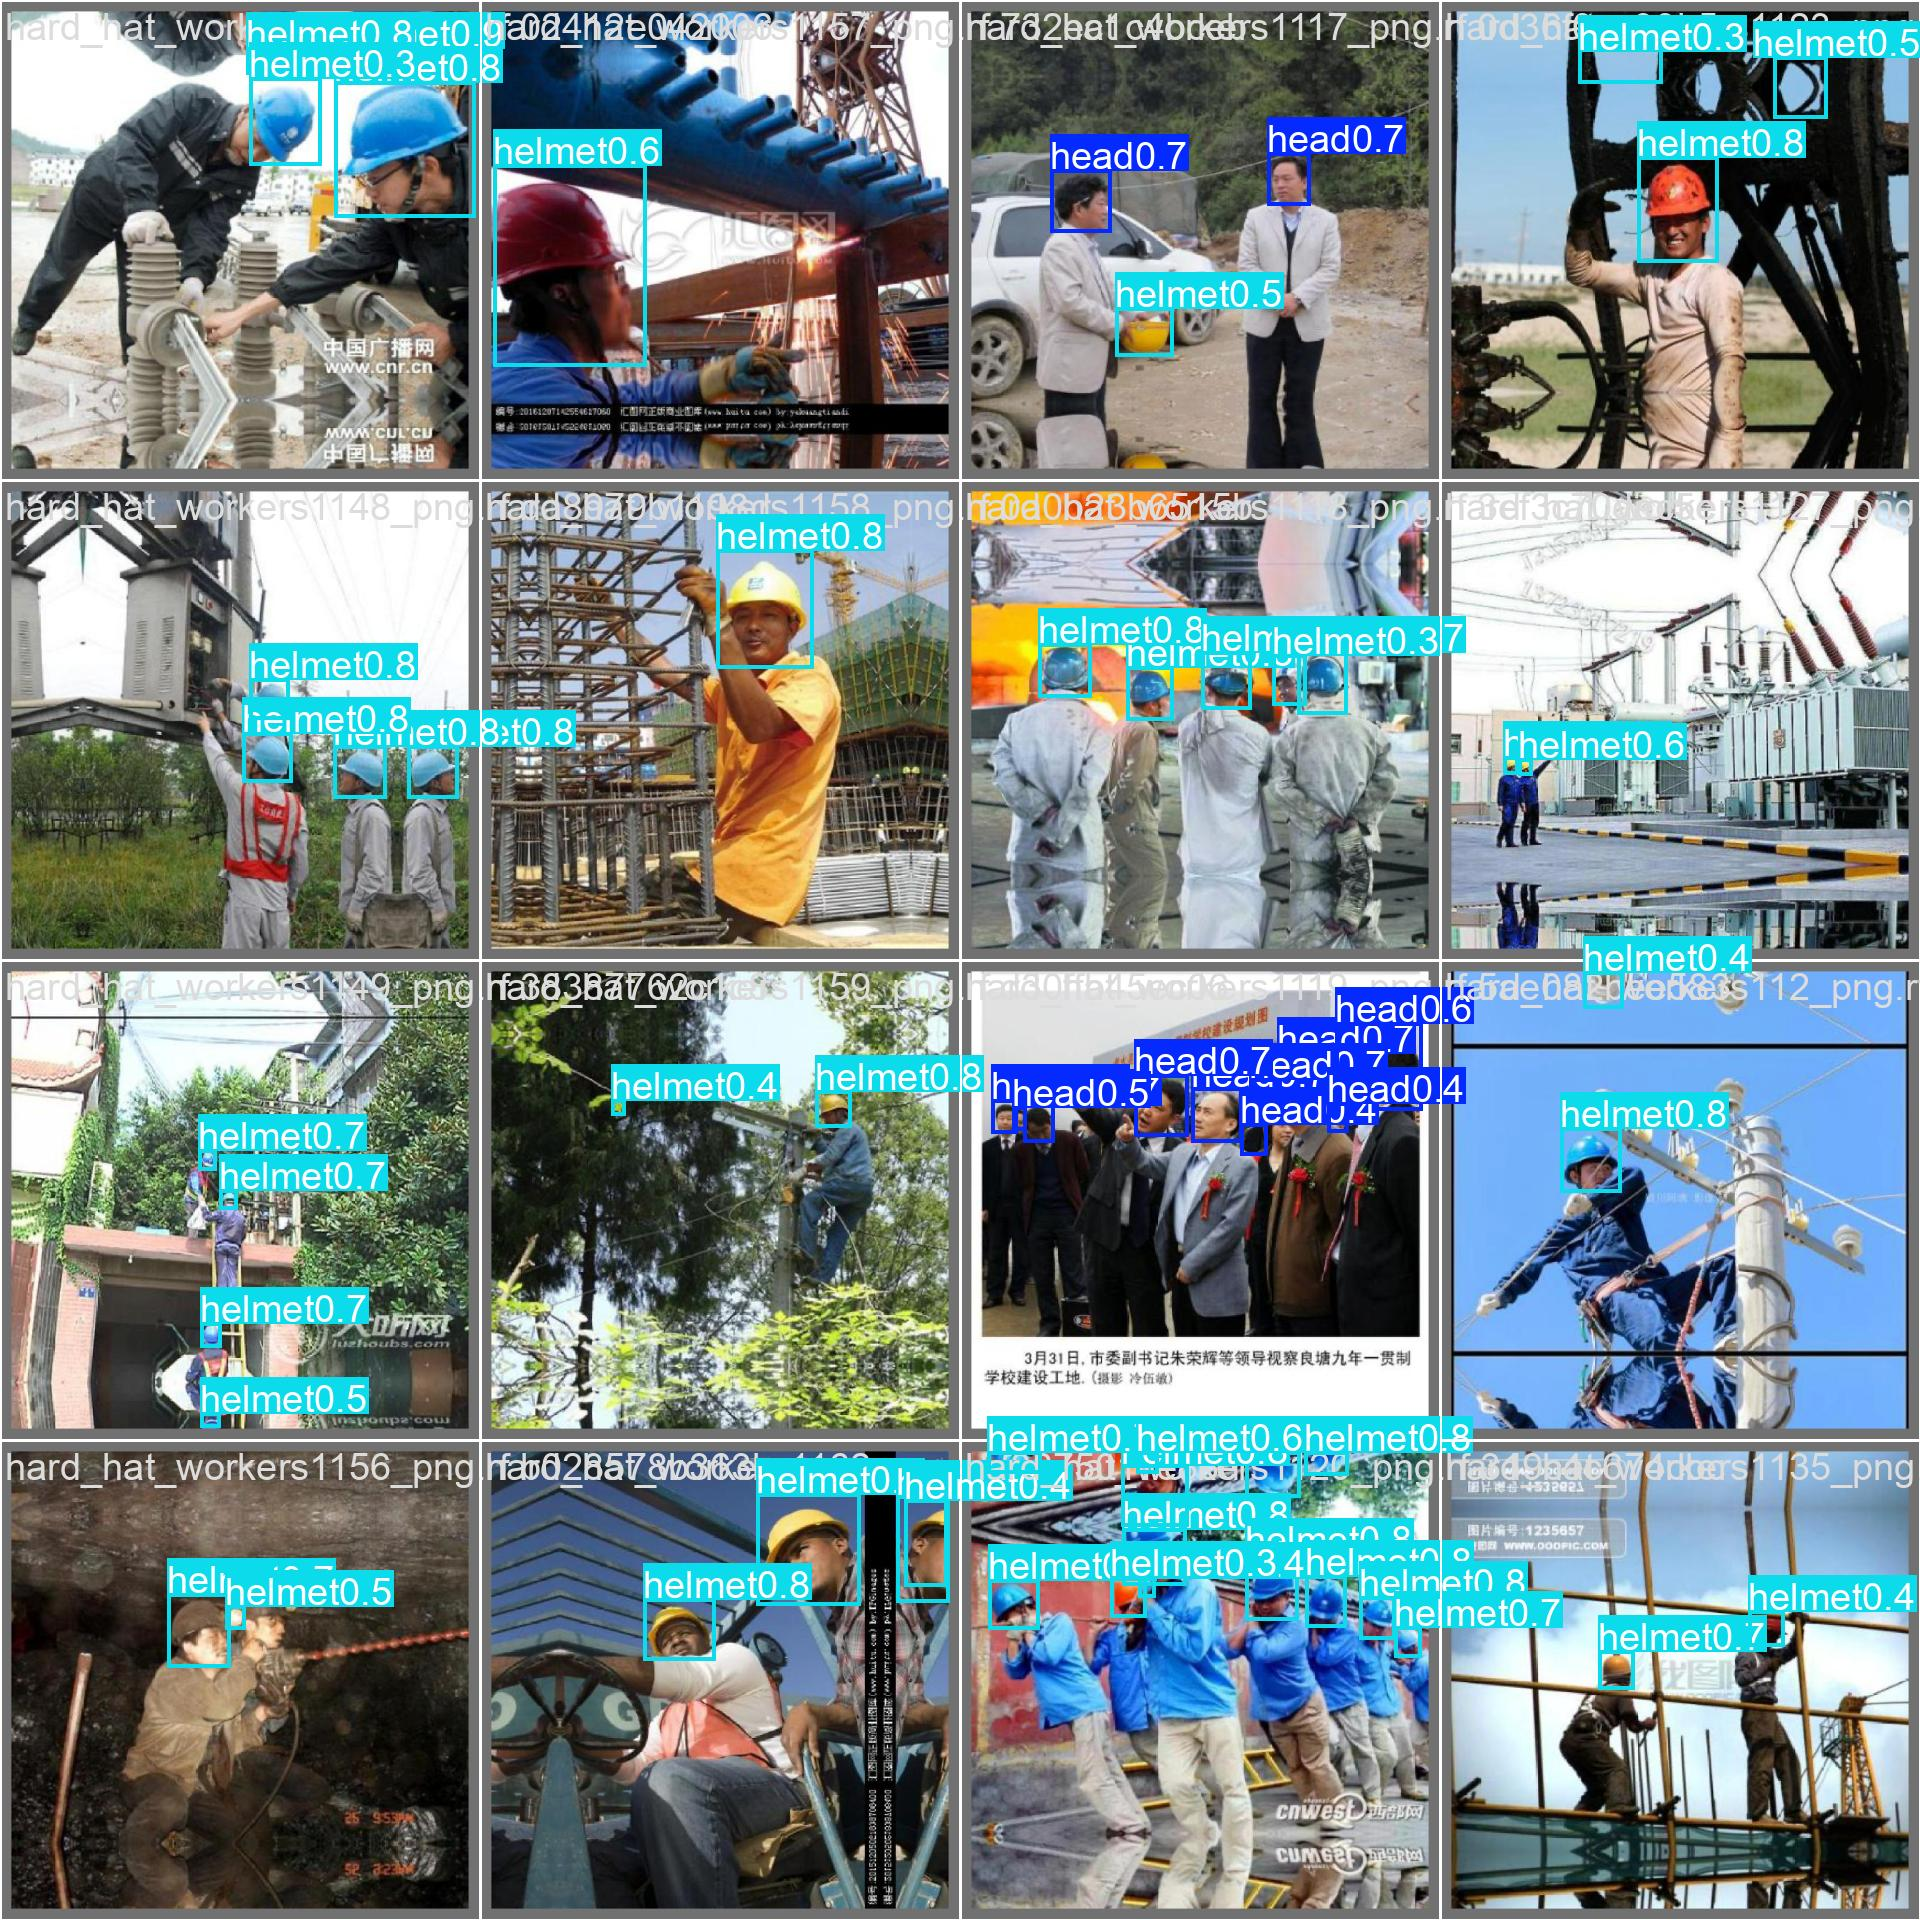

In [ ]:
Image('/content/runs/detect/Hard-Hat-Detection-1/yolov8m_2class/val_batch1_pred.jpg')

Sebagian besar objek berhasil terdeteksi dengan nilai confidence yang cukup tinggi, umumnya berada pada rentang 0,5–0,8, yang menunjukkan tingkat keyakinan prediksi yang baik. Model juga mampu mengenali objek pada berbagai ukuran, sudut pandang, dan jumlah pekerja dalam satu gambar. Namun, masih terlihat beberapa prediksi dengan confidence yang relatif rendah serta kemungkinan deteksi yang kurang akurat akibat kondisi objek yang tertutup (occlusion) dan kepadatan kerumunan